In [1]:
using FluorescenceCorrelationFitting

In [2]:
filepath = "sample1.txt"
data = read_fcs(filepath);

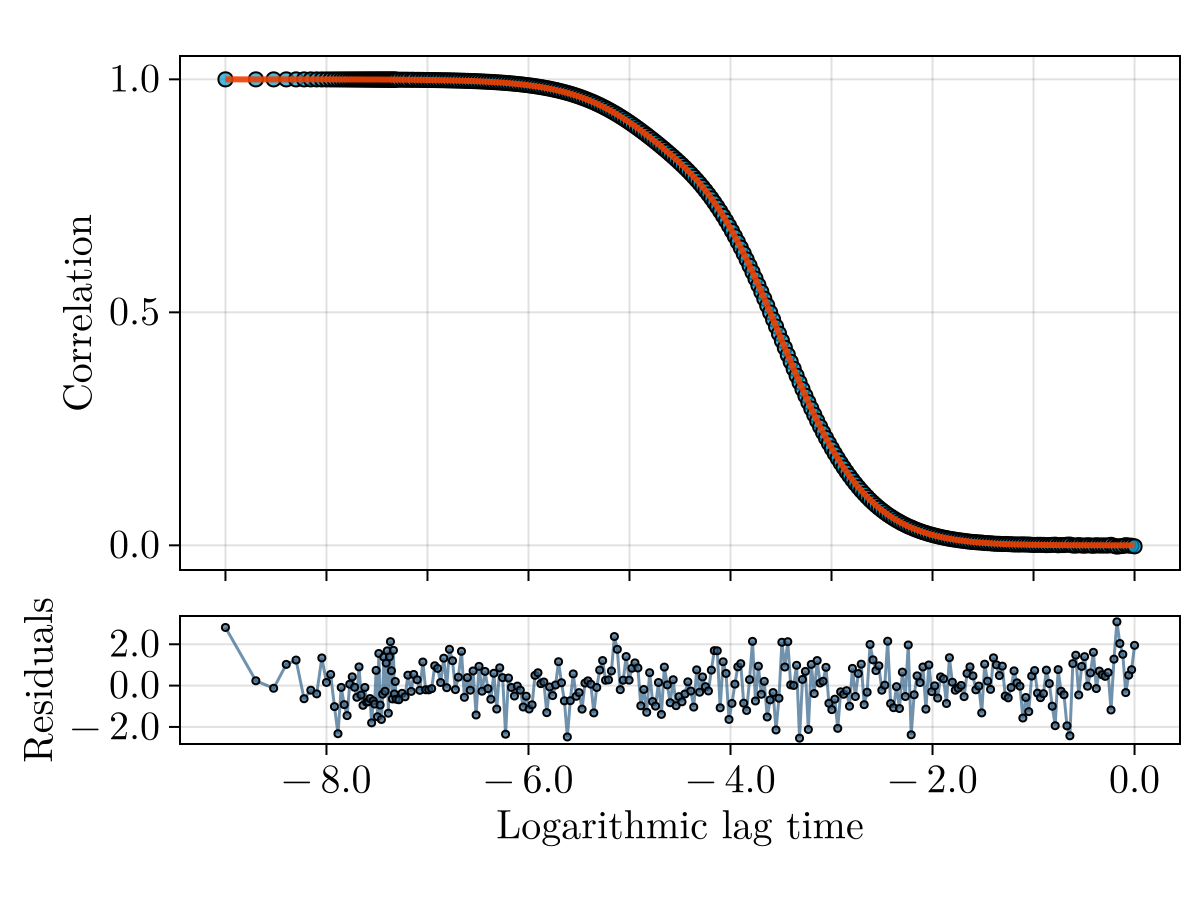

In [3]:
using CairoMakie, LaTeXStrings

diffusivity=5e-11; offset=0.0
spec = FCSModelSpec(dim = FluorescenceCorrelationFitting.d3, anom = FluorescenceCorrelationFitting.none, offset = offset, diffusivity = diffusivity)

initial_parameters = [1.0, 5, 2e-7, 1e-7, 0.1]
lower_bounds = [0.9, 1, 1e-8, 1e-8, 0.0]
upper_bounds = [1.1, 20, 1e-6, 1e-4, 0.5]
fit = fcs_fit(spec, data.channels[3], initial_parameters; lower = lower_bounds, upper = upper_bounds)
fig, _ = fcs_plot(fit, data.channels[3])
fig

In [4]:
using PrettyTables

fcs_table(fit; units=["", "", "μ", "μ", ""], gof_metric=aic)

Parameters 
 Values 
 Std. Dev. 
 
 
 
 
 Current amplitude 
 1 
 2.479e-7 
 
 
 Structure factor 
 7.996 
 0.01089 
 
 
 Beam width [μm] 
 0.25 
 7.676e-6 
 
 
 Dynamic lifetime 1 [μs] 
 10 
 7.845e-4 
 
 
 Dynamic population fraction 1 
 0.1 
 6.537e-6 
 
 
 
 
 aic = 2377.31

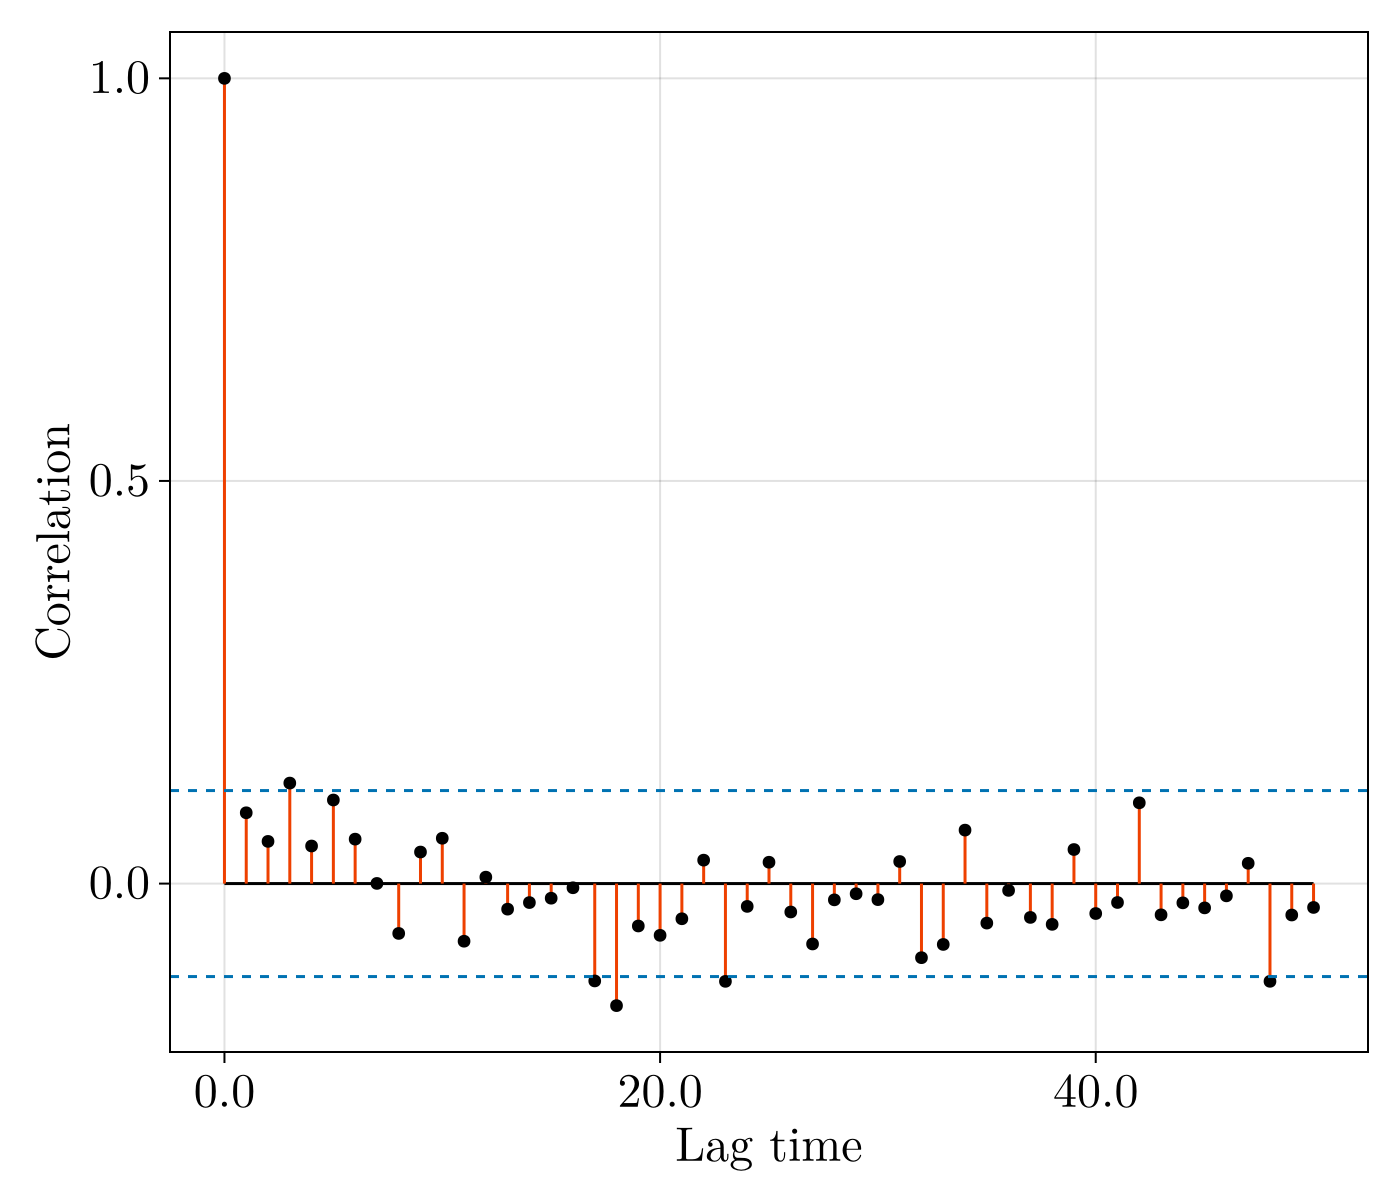

In [5]:
fig = resid_acf_plot(fit; 
    acf_kwargs=(maxlag=50,), 
    plot_kwargs=(
        figure_kw=(size=(700,600),fontsize=24), 
        stem_kw=(stemcolor=:orangered2, color=:black, trunkcolor=:black), 
        hline_kw=(linestyle=:dash,)
    )
)
fig